CLASSIFICATION vs REGRESSION

Both classification and regression are types of
supervised learning — you train on labelled examples.
The key
difference is in what you predict:

In [ ]:
import numpy as np
from sklearn.linear_model import LinearRegression, LogisticRegression

X = np.array([[1],[2],[3],[4],[5],[6],[7],[8]])
y_reg = np.array([30, 40, 45, 55, 65, 70, 80, 90])
y_cls = np.array([0, 0, 0, 0, 1, 1, 1, 1])

lin = LinearRegression()
lin.fit(X, y_reg)

print('Regression output:', lin.predict([[5.5]]))

log = LogisticRegression()
log.fit(X, y_cls)

print('Classification output:', log.predict([[5.5]]))

print('Probability output:', log.predict_proba([[5.5]]))

  THE SIGMOID CURVE

The sigmoid function takes any real number as input and squashes it into the range [0, 1]. This output is interpreted as
a probability.

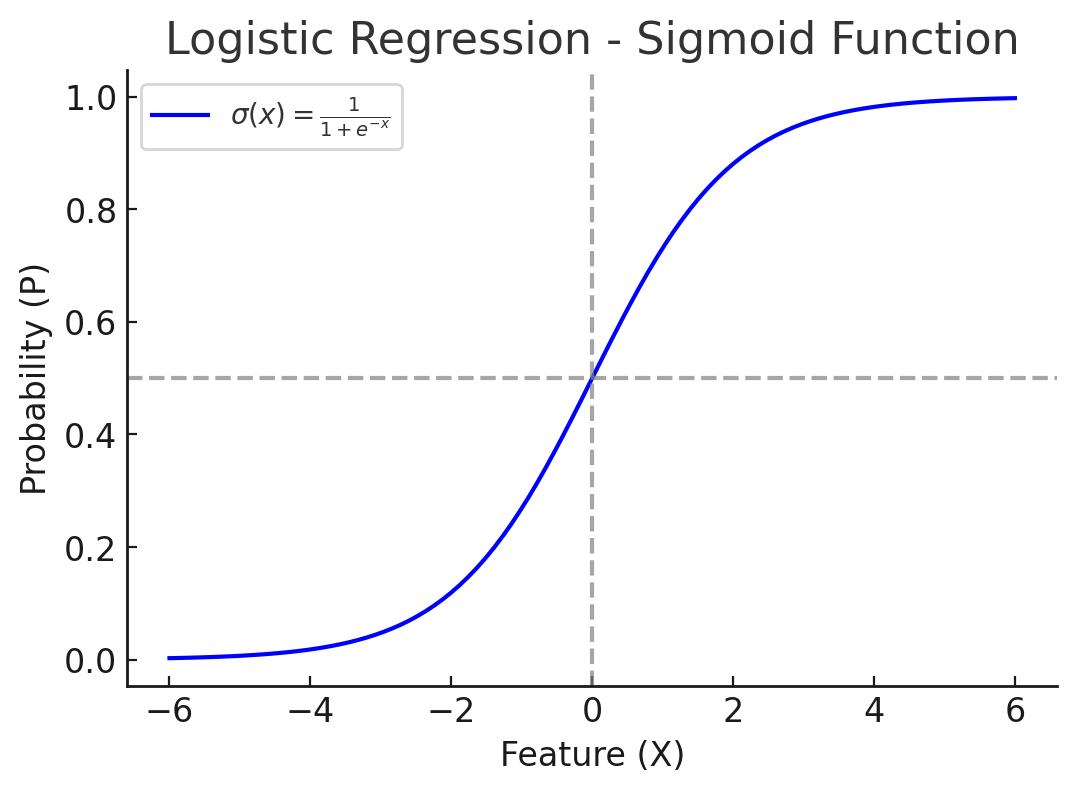


X in the image represents output prediction.

if x is large postive number ->σ(x) → 1.0 (very likely YES) • If x is a large negative
number → σ(x) → 0.0 (very likely NO) • If z = 0 → σ(x) = 0.5 (uncertain — right on the
fence)

Output Probability	Meaning
0.1	Very unlikely
0.4	Maybe No
0.7	Maybe Yes
0.95	Almost Yes

According to above diagram and explanation what sigma curve is going to if number is big we are going to predict it as yes or no.

what if number is in middle or uncertain oreder for example like in above table , if we get 0.73 how we are going to decide whether it is yes or no.

to understand that we need to know few rules

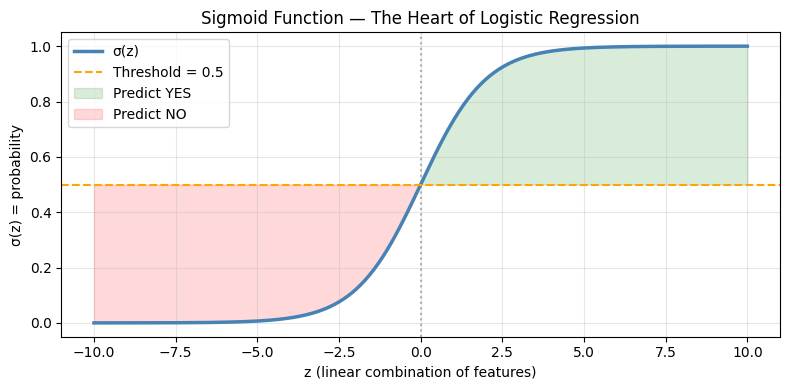

sigmoid(0) = 0.5000
sigmoid(5) = 0.9933
sigmoid(-5) = 0.0067


In [1]:
import numpy as np
import matplotlib.pyplot as plt

def sigmoid(z):
    return 1 / (1 + np.exp(-z))

z = np.linspace(-10, 10, 300)

prob = sigmoid(z)

plt.figure(figsize=(8, 4))
plt.plot(z, prob, color='steelblue', linewidth=2.5, label='σ(z)')
plt.axhline(y=0.5, color='orange', linestyle='--', label='Threshold = 0.5')
plt.axvline(x=0, color='gray', linestyle=':', alpha=0.6)

plt.fill_between(
    z, prob, 0.5,
    where=(prob > 0.5),
    alpha=0.15,
    color='green',
    label='Predict YES'
)

plt.fill_between(
    z, prob, 0.5,
    where=(prob < 0.5),
    alpha=0.15,
    color='red',
    label='Predict NO'
)

plt.xlabel('z (linear combination of features)')
plt.ylabel('σ(z) = probability')
plt.title('Sigmoid Function — The Heart of Logistic Regression')

plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print(f'sigmoid(0) = {sigmoid(0):.4f}')
print(f'sigmoid(5) = {sigmoid(5):.4f}')
print(f'sigmoid(-5) = {sigmoid(-5):.4f}')

Decision Threshold

The sigmoid gives us a probability (e.g., 0.73). We need a rule to convert that into a class label. The default rule is
called the decision threshold:

Probability > 0.5 → YES

Probability < 0.5 → NO

Probability	Prediction
0.82	Spam
0.23	Not Spam
0.91	Disease
0.15	Healthy


In [2]:
from sklearn.datasets import make_classification
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import precision_score, recall_score, f1_score
from sklearn.model_selection import train_test_split

X, y = make_classification(
    n_samples=500,
    n_features=5,
    weights=[0.7, 0.3],
    random_state=42
)

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

model = LogisticRegression()

model.fit(X_train, y_train)

probs = model.predict_proba(X_test)[:, 1]

print(f"{'Threshold':>10} {'Precision':>10} {'Recall':>8} {'F1':>6}")
print("-" * 45)

for threshold in [0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8]:
    preds = (probs >= threshold).astype(int)

    p = precision_score(y_test, preds, zero_division=0)
    r = recall_score(y_test, preds)
    f = f1_score(y_test, preds, zero_division=0)

    print(f"{threshold:>10.1f} {p:>10.3f} {r:>8.3f} {f:>6.3f}")

 Threshold  Precision   Recall     F1
---------------------------------------------
       0.2      0.696    0.941  0.800
       0.3      0.762    0.941  0.842
       0.4      0.882    0.882  0.882
       0.5      0.882    0.882  0.882
       0.6      0.903    0.824  0.862
       0.7      0.903    0.824  0.862
       0.8      0.958    0.676  0.793


### **Confusion Matrix**

A **Confusion Matrix** is used to evaluate the performance of a classification model. It compares actual values with predicted values and helps calculate metrics like Accuracy, Precision, and Recall.

**Key Terms:**

* **TP (True Positive):** Correct positive predictions
* **TN (True Negative):** Correct negative predictions
* **FP (False Positive):** Incorrect positive predictions
* **FN (False Negative):** Incorrect negative predictions

This program calculates the confusion matrix manually and using Scikit-learn, then visualizes the results.


TP=5, TN=4, FP=3, FN=3
Accuracy = (TP+TN)/Total = (5+4)/15 = 60.00%
Precision = TP/(TP+FP) = 5/8 = 62.50%
Recall = TP/(TP+FN) = 5/8 = 62.50%
Confusion matrix:
 [[4 3]
 [3 5]]


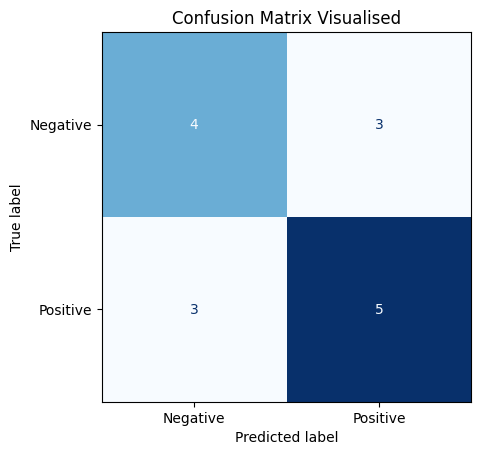

In [3]:
import numpy as np
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

y_true = [1,1,1,1,1,0,0,0,0,0,1,0,1,0,1]
y_pred = [1,1,1,0,0,0,0,0,1,1,1,0,0,1,1]

y_true = np.array(y_true)
y_pred = np.array(y_pred)

TP = ((y_pred == 1) & (y_true == 1)).sum()
TN = ((y_pred == 0) & (y_true == 0)).sum()
FP = ((y_pred == 1) & (y_true == 0)).sum()
FN = ((y_pred == 0) & (y_true == 1)).sum()

print(f'TP={TP}, TN={TN}, FP={FP}, FN={FN}')
print(f'Accuracy = (TP+TN)/Total = ({TP}+{TN})/{len(y_true)} = {(TP+TN)/len(y_true):.2%}')
print(f'Precision = TP/(TP+FP) = {TP}/{TP+FP} = {TP/(TP+FP):.2%}')
print(f'Recall = TP/(TP+FN) = {TP}/{TP+FN} = {TP/(TP+FN):.2%}')

cm = confusion_matrix(y_true, y_pred)
print('Confusion matrix:\n', cm)

disp = ConfusionMatrixDisplay(cm, display_labels=['Negative', 'Positive'])
disp.plot(cmap='Blues', colorbar=False)

plt.title('Confusion Matrix Visualised')
plt.show()

# Precision, Recall and F1-score

Precision, Recall and F1-score are used to evaluate classification models, especially in imbalanced datasets. Accuracy can be misleading when one class dominates, because the model may predict only the majority class and still get high accuracy. Precision tells how many predicted positives are correct, recall tells how many actual positives are correctly found, and F1-score is the balance of both. In imbalanced data, F1-score is more important than accuracy. Using `class_weight='balanced'` helps the model pay attention to minority classes.


In [4]:
from sklearn.datasets import make_classification
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, f1_score, accuracy_score
from sklearn.model_selection import train_test_split
import numpy as np

X_bal, y_bal = make_classification(n_samples=1000, weights=[0.5, 0.5], random_state=1)

X_imb, y_imb = make_classification(n_samples=1000, weights=[0.99, 0.01], random_state=1)

def evaluate(X, y, label):
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
    model = LogisticRegression(max_iter=1000).fit(X_train, y_train)
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred, zero_division=0)

    print(f"\n=== {label} ===")
    print(f"Accuracy : {acc:.2%}")
    print(f"F1 Score : {f1:.2%}")
    print(classification_report(y_test, y_pred, zero_division=0))

evaluate(X_bal, y_bal, "balanced data")
evaluate(X_imb, y_imb, "imbalanced data")

X_train, X_test, y_train, y_test = train_test_split(X_imb, y_imb, test_size=0.2, random_state=42)

model_fixed = LogisticRegression(class_weight='balanced', max_iter=1000)
model_fixed.fit(X_train, y_train)

y_pred_fixed = model_fixed.predict(X_test)

print("\n=== After class_weight=balanced ===")
print(classification_report(y_test, y_pred_fixed, zero_division=0))


=== balanced data ===
Accuracy : 80.50%
F1 Score : 80.00%
              precision    recall  f1-score   support

           0       0.84      0.78      0.81       106
           1       0.77      0.83      0.80        94

    accuracy                           0.81       200
   macro avg       0.81      0.81      0.80       200
weighted avg       0.81      0.81      0.81       200


=== imbalanced data ===
Accuracy : 97.50%
F1 Score : 0.00%
              precision    recall  f1-score   support

           0       0.98      0.99      0.99       196
           1       0.00      0.00      0.00         4

    accuracy                           0.97       200
   macro avg       0.49      0.50      0.49       200
weighted avg       0.96      0.97      0.97       200


=== After class_weight=balanced ===
              precision    recall  f1-score   support

           0       0.98      0.89      0.93       196
           1       0.04      0.25      0.07         4

    accuracy              

ROC CURVE & AUC

The ROC Curve plots True Positive Rate (Recall) vs False Positive Rate across every possible threshold — giving a
complete picture of your model's discriminating power. AUC (Area Under Curve) is a single number summarising the
whole curve.

| Axis   | Meaning                     |
| ------ | --------------------------- |
| X-axis | False alarms                |
| Y-axis | Correct positive detections |


| AUC Score | Meaning         |
| --------- | --------------- |
| 0.5       | Random guessing |
| 0.7       | Good            |
| 0.8       | Very good       |
| 0.9+      | Excellent       |


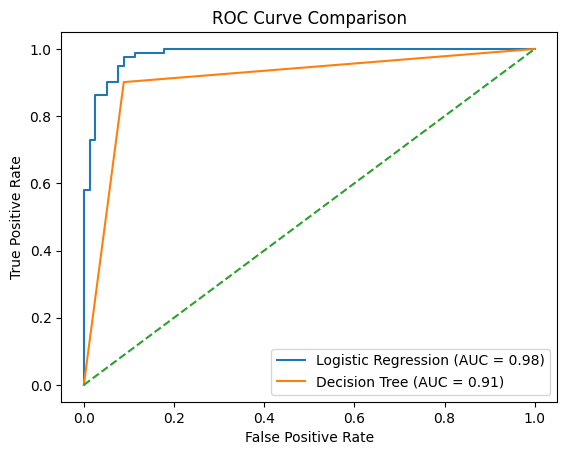

In [6]:
from sklearn.datasets import make_classification
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import roc_curve, roc_auc_score
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

X, y = make_classification(n_samples=800, n_features=10, random_state=42)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

log_model = LogisticRegression()
tree_model = DecisionTreeClassifier()

log_model.fit(X_train, y_train)
tree_model.fit(X_train, y_train)

log_probs = log_model.predict_proba(X_test)[:, 1]
tree_probs = tree_model.predict_proba(X_test)[:, 1]

fpr_log, tpr_log, _ = roc_curve(y_test, log_probs)
fpr_tree, tpr_tree, _ = roc_curve(y_test, tree_probs)

auc_log = roc_auc_score(y_test, log_probs)
auc_tree = roc_auc_score(y_test, tree_probs)

plt.plot(fpr_log, tpr_log, label=f"Logistic Regression (AUC = {auc_log:.2f})")
plt.plot(fpr_tree, tpr_tree, label=f"Decision Tree (AUC = {auc_tree:.2f})")

plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend()
plt.show()